
# Word2Vec

### Alfio Ferrara

## A simple toy dataset
Let's take a simple example with pseudo docs representing different weather conditions

In [1]:
import json

In [2]:
with open('./data/weather.json', 'r') as file_in:
    data = json.load(file_in)
weather = data['weather']
for doc in weather:
    print(" | ".join(doc))

montagna | neve | ghiaccio | picco | bosco | freddo
spiaggia | sabbia | mare | onda | sole | caldo
deserto | duna | cactus | sabbia | sole | arido
foresta | albero | foglia | animale | pioggia | umidità
fiume | acqua | pesce | primavera | corrente | pozza
cielo | nuvola | vento | pioggia | tuono | arcobaleno
lago | acqua | barca | pesce | riva | tranquillità
vulcano | lava | roccia | fumo | cratere | calore
prato | erba | fiore | ape | sole
notte | luna | stella | buio | silenzio | ombra
collina | sentiero | erba | vento | tramonto | orizzonte
tempesta | vento | pioggia | fulmine | mare
grotta | roccia | buio | eco | acqua
inverno | neve | freddo | ghiaccio | vento | brina
foglia | pioggia | vento | terra
primavera | fiore | sole | erba


## Create SkipGram dataloader

In [80]:
import wordbags as wb
import pandas as pd
import torch 

In [81]:
bow = wb.Bow(corpus=weather)
data_loader, inputs, outputs = bow.one_hot_skip_gram_dataloader(window=4, batch=2)

In [82]:
readable_input = pd.DataFrame(inputs, columns=bow.vocabulary)
readable_input.iloc[2].head()

montagna   0.000000
neve       0.000000
ghiaccio   1.000000
picco      0.000000
bosco      0.000000
Name: 2, dtype: float32

In [83]:
readable_target = pd.DataFrame(outputs, columns=bow.vocabulary)
readable_target.iloc[2].head()

montagna   1.000000
neve       1.000000
ghiaccio   0.000000
picco      1.000000
bosco      1.000000
Name: 2, dtype: float32

In [84]:
for x, y in data_loader:
    print(f"Input: {x}")
    print(f"Target: {y}")
    break 

Input: tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
Target: tensor([[0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.,

In [85]:
for i, (x, y) in enumerate(data_loader):
    for batch_i in range(x.shape[0]):
        x_indices = torch.where(x[batch_i] == 1)[0].numpy()
        y_indices = torch.where(y[batch_i] == 1)[0].numpy()
        input_word = f"{[bow.idx2word[w_x] for w_x in x_indices]}"
        target_word = f"{[bow.idx2word[w_y] for w_y in y_indices]}"
        print(f"{input_word} ==> {target_word}")
    if i > 5:
        break 

['montagna'] ==> ['neve', 'ghiaccio', 'picco', 'bosco']
['neve'] ==> ['montagna', 'ghiaccio', 'picco', 'bosco', 'freddo']
['ghiaccio'] ==> ['montagna', 'neve', 'picco', 'bosco', 'freddo']
['picco'] ==> ['montagna', 'neve', 'ghiaccio', 'bosco', 'freddo']
['bosco'] ==> ['montagna', 'neve', 'ghiaccio', 'picco', 'freddo']
['freddo'] ==> ['neve', 'ghiaccio', 'picco', 'bosco']
['spiaggia'] ==> ['sabbia', 'mare', 'onda', 'sole']
['sabbia'] ==> ['spiaggia', 'mare', 'onda', 'sole', 'caldo']
['mare'] ==> ['spiaggia', 'sabbia', 'onda', 'sole', 'caldo']
['onda'] ==> ['spiaggia', 'sabbia', 'mare', 'sole', 'caldo']
['sole'] ==> ['spiaggia', 'sabbia', 'mare', 'onda', 'caldo']
['caldo'] ==> ['sabbia', 'mare', 'onda', 'sole']
['deserto'] ==> ['sabbia', 'sole', 'duna', 'cactus']
['duna'] ==> ['sabbia', 'sole', 'deserto', 'cactus', 'arido']


## Build and train a predictor

In [86]:
from wordvec import Word2WordPrediction, Word2VecModel
from w2w_readers import WordEmbeddings

In [87]:
bow.size 

64

In [88]:
w2w = Word2WordPrediction(input_dim=bow.size, hidden_dim=6)
model_untrained = WordEmbeddings(words=bow, model=w2w)

In [89]:
query = 'deserto'
next_word = model_untrained.predict(query, topk=10)
print(next_word)


sabbia      0.016861
bosco       0.016827
nuvola      0.016775
calore      0.016699
foresta     0.016421
neve        0.016372
primavera   0.016369
cratere     0.016215
lava        0.016209
montagna    0.016146
dtype: float32


**Training**

In [90]:
epochs = 150
learning_rate = 0.01
history = w2w.train(data_loader=data_loader, epochs=epochs, 
                    learning_rate=learning_rate)
print(history[0], history[-1])

100%|██████████| 150/150 [00:00<00:00, 161.71it/s]

18.252855767144098 17.48019602033827


### Predict next word

In [91]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [92]:
model = WordEmbeddings(words=bow, model=w2w)

In [93]:
model['fiume']

array([-0.05008461,  0.4488829 , -1.587033  ,  1.1961783 ,  0.93607765,
       -0.7301154 ], dtype=float32)

In [94]:
query = 'deserto'
next_word = model.predict(query, topk=10)
next_word

sole      0.702108
sabbia    0.297703
erba      0.000037
freddo    0.000014
fumo      0.000010
duna      0.000009
onda      0.000008
neve      0.000006
cactus    0.000006
cratere   0.000005
dtype: float32

### Generate text

In [95]:
import numpy as np 

In [96]:
start = "deserto"
already_chosen = set()
text = [start]
for i in range(6):
    p = model.predict(start)
    run = True
    while run:
        next_word = np.random.choice(p.index.values, p=p.values / p.values.sum())
        if next_word in already_chosen:
            run = True
        else:
            text.append(next_word)
            already_chosen.add(next_word)
            run = False
    start = next_word

print(" ".join(text))

deserto sole sabbia erba vento pioggia neve


## Word Embeddings

In [97]:
search = 'deserto'

In [98]:
model[search]

array([-0.5873314 , -0.74280775, -1.0065097 , -0.90409666, -0.9825293 ,
        1.2641437 ], dtype=float32)

### Most similar

In [99]:
model.most_similar(search, topk=10)

deserto    1.000000
arido      0.999262
cactus     0.993196
spiaggia   0.980358
duna       0.979481
caldo      0.978697
mare       0.968513
onda       0.962495
sabbia     0.627999
sole       0.627312
Name: deserto, dtype: float32

### Visual map

In [100]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-dark-palette')

In [101]:
tsne = TSNE(n_components=2)
vectors = model.vectors(bow.vocabulary)
v2d = tsne.fit_transform(vectors)

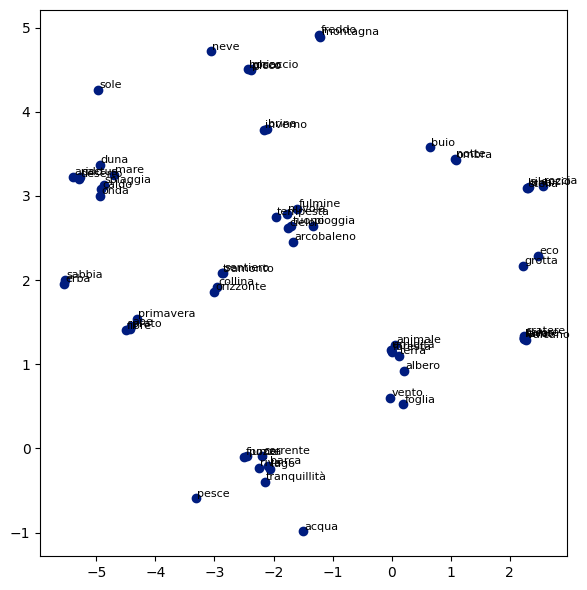

In [102]:
selected_words = bow.vocabulary
indexes = [bow.word2idx[w] for w in selected_words]
selected2d = v2d[indexes]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(selected2d[:,0], selected2d[:, 1])
for i, w in enumerate(selected_words):
    ax.text(selected2d[i][0] + .02, selected2d[i][1] + .02, w, fontsize=8)
plt.tight_layout()
plt.show()

### Clustering

In [103]:
from sklearn.cluster import AffinityPropagation
from collections import defaultdict
import seaborn as sns

In [104]:
ap = AffinityPropagation()
assignments = ap.fit_predict(selected2d)
clusters = defaultdict(list)
for i, cluster in enumerate(assignments):
    clusters[cluster].append(selected_words[i])

/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [105]:
for cluster, words in clusters.items():
    print(f"Cluster {cluster}: {', '.join(words)}")

Cluster 0: montagna, neve, ghiaccio, picco, bosco, freddo, inverno, brina
Cluster 1: spiaggia, sabbia, mare, onda, sole, caldo, deserto, duna, cactus, arido, primavera, prato, erba, fiore, ape
Cluster 2: foresta, albero, foglia, animale, umidità, vento, terra
Cluster 4: pioggia, cielo, nuvola, tuono, arcobaleno, collina, sentiero, tramonto, orizzonte, tempesta, fulmine
Cluster 3: fiume, acqua, pesce, corrente, pozza, lago, barca, riva, tranquillità
Cluster 5: vulcano, lava, roccia, fumo, cratere, calore, notte, luna, stella, buio, silenzio, ombra, grotta, eco


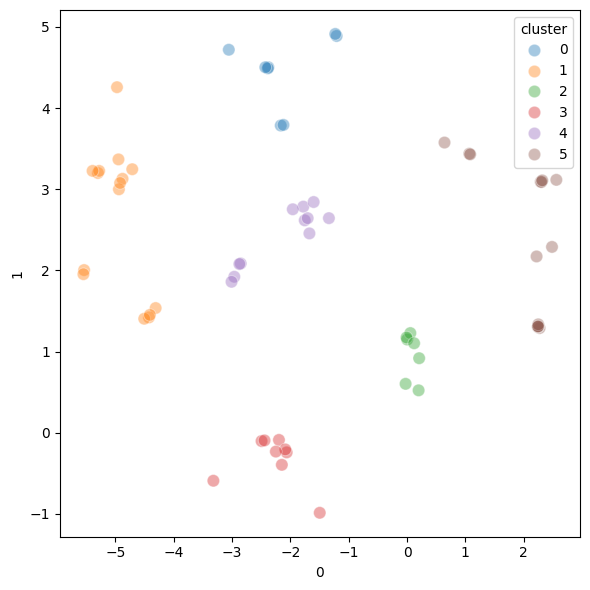

In [106]:
dfsample = pd.DataFrame(selected2d)
dfsample['word'] = selected_words
dfsample['cluster'] = assignments


fig, ax = plt.subplots(figsize=(6, 6))
scatter = sns.scatterplot(
    data=dfsample,
    x=0,
    y=1,
    hue="cluster",
    s=80,
    palette="tab10",
    legend="full",
    ax=ax,
    alpha=0.4
)
# for i in range(len(dfsample)):
#     plt.text(dfsample[0][i] + 0.01, dfsample[1][i], dfsample.word[i], fontsize=6)
plt.tight_layout()
plt.show()

### Directions

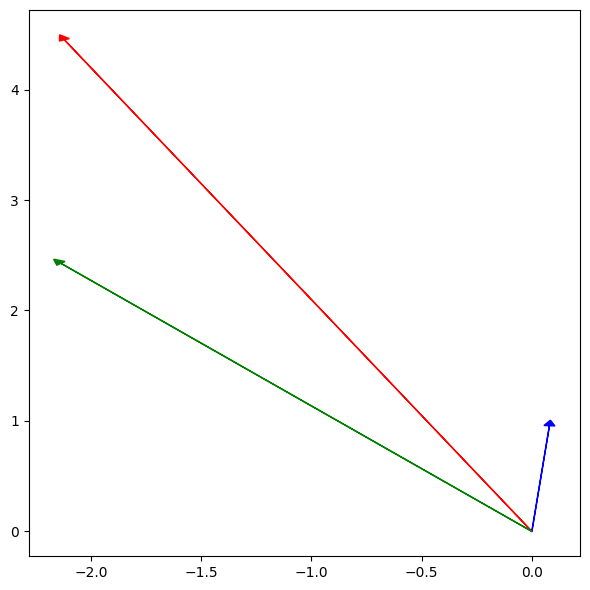

Gruppo 1: ['montagna', 'neve', 'ghiaccio', 'picco', 'bosco', 'freddo', 'inverno', 'brina']
Gruppo 2: ['foresta', 'albero', 'foglia', 'animale', 'umidità', 'vento', 'terra']
Gruppo 3: ['pioggia', 'cielo', 'nuvola', 'tuono', 'arcobaleno', 'collina', 'sentiero', 'tramonto', 'orizzonte', 'tempesta', 'fulmine']


In [107]:
def pointer(group, vectors):
    g = vectors[[bow.word2idx[w] for w in group]]
    return g.mean(axis=0)

group1 = clusters[0]
group2 = clusters[2]
group3 = clusters[4]
g1 = pointer(group1, v2d)
g2 = pointer(group2, v2d)
g3 = pointer(group3, v2d)

fig, ax = plt.subplots(figsize=(6, 6))
ax.arrow(0, 0, g1[0], g1[1], head_width=0.05, head_length=0.05, fc='red', ec='red')
ax.arrow(0, 0, g2[0], g2[1], head_width=0.05, head_length=0.05, fc='blue', ec='blue')
ax.arrow(0, 0, g3[0], g3[1], head_width=0.05, head_length=0.05, fc='green', ec='green')
plt.tight_layout()
plt.show()

print(f"Gruppo 1: {group1}")
print(f"Gruppo 2: {group2}")
print(f"Gruppo 3: {group3}")

## Compositionality

In [108]:
model.search(positive=['mare', 'spiaggia'])

spiaggia   0.998907
mare       0.998687
caldo      0.997192
duna       0.996357
onda       0.993495
cactus     0.989900
arido      0.976149
deserto    0.975876
sole       0.642504
sabbia     0.632814
dtype: float32

In [109]:
model.search(positive=['mare'], negative=['spiaggia'])

vento     0.900663
foglia    0.863038
umidità   0.824469
foresta   0.824279
albero    0.819833
terra     0.792829
animale   0.770953
fulmine   0.436360
pesce     0.429787
pioggia   0.404040
dtype: float32

In [ ]:
model.search(positive=['deserto'], negative=['sole'])

In [110]:
answer, a_vector = model.analogy('mare', 'onda', 'deserto')
print(answer)

arido


In [111]:
model.common_meanings(['mare', 'onda', 'deserto', 'sabbia'])

caldo      0.962865
spiaggia   0.962354
duna       0.957273
cactus     0.953833
mare       0.952168
onda       0.951639
deserto    0.948736
arido      0.946772
sabbia     0.823890
erba       0.801640
dtype: float32

In [112]:
model.spot_odd_one(words=['montagna', 'picco', 'neve', 'sabbia'])

montagna   0.388582
sabbia     0.456476
neve       0.790304
picco      0.924587
dtype: float32

In [ ]:
model.search(positive=['mare'], negative=['onda'])

In [ ]:
model.search(positive=['duna', 'mare'], negative=['onda'])